In [1]:
import src.datasets as ds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_samples, silhouette_score

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'wurlitzer', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [ ]:
from torch_geometric.datasets import Planetoid, Coauthor, Amazon
from torch_geometric.utils import degree
import pandas as pd
dataset = Planetoid(root="dataset", name='cora')
data = dataset[0]

degrees = degree(data.edge_index[0], num_nodes=data.num_nodes)
average_degree = pd.Series(degrees.float().tolist()).describe()
print(f"Degré Moyen des Nœuds : {average_degree}")

Degré Moyen des Nœuds : count    2708.000000
mean        3.898080
std         5.228784
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max       168.000000
dtype: float64


In [6]:
def elbow_plot(name):
    data, _ = ds.loaddataset(name)
    if hasattr(data, "_pos"):
        pos = []
        for p in data._pos:
            x, y = p.split(", ")
            pos.append([float(x), float(y)])
    else:
        assert("No Kmeans without pos!!")

    X = np.array(pos)
    sse = {}
    for n_clusters in range(int(data.num_nodes/100), int(data.num_nodes/2), int((data.num_nodes/2)/100)):
        kmeans = KMeans(n_clusters=n_clusters, max_iter=1000).fit(X)
        #print(data["clusters"])
        sse[n_clusters] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
    print(sse)
    print(len(sse))
    plt.figure(figsize=(30, 6))
    plt.plot(list(sse.keys()), list(sse.values()))
    plt.xlabel("Number of cluster")
    plt.ylabel("SSE")
    plt.title(name+' elbow method')
    plt.xticks(list(sse.keys()), rotation=90, fontsize=12)
    plt.show()

{13: 1001.6433838864915, 19: 725.5768814512861, 25: 480.63507131359466, 31: 360.0715983679577, 37: 310.71619193513436, 43: 262.2728008173884, 49: 219.22477521434345, 55: 196.33045733246556, 61: 164.2858425104887, 67: 150.53590684392077, 73: 135.40046907445907, 79: 125.03517709226693, 85: 112.47016033689783, 91: 103.26795413745727, 97: 94.70597943118543, 103: 87.61391221678903, 109: 84.25510238478162, 115: 77.83808375253714, 121: 72.15987183782198, 127: 65.73985979326307, 133: 64.55311204860378, 139: 59.287424832042866, 145: 56.04920135285051, 151: 52.7343381521355, 157: 51.8138037447365, 163: 48.6515168546936, 169: 46.57443287216512, 175: 44.21377087710661, 181: 42.814595342279695, 187: 40.30302145274229, 193: 38.629138477967025, 199: 38.16165187818564, 205: 36.42813662227185, 211: 34.76918958255355, 217: 33.01288491897964, 223: 32.15363923910584, 229: 30.349082024053516, 235: 29.9065764144345, 241: 28.34416405019689, 247: 27.53075411111957, 253: 26.429978103014427, 259: 25.83339553391

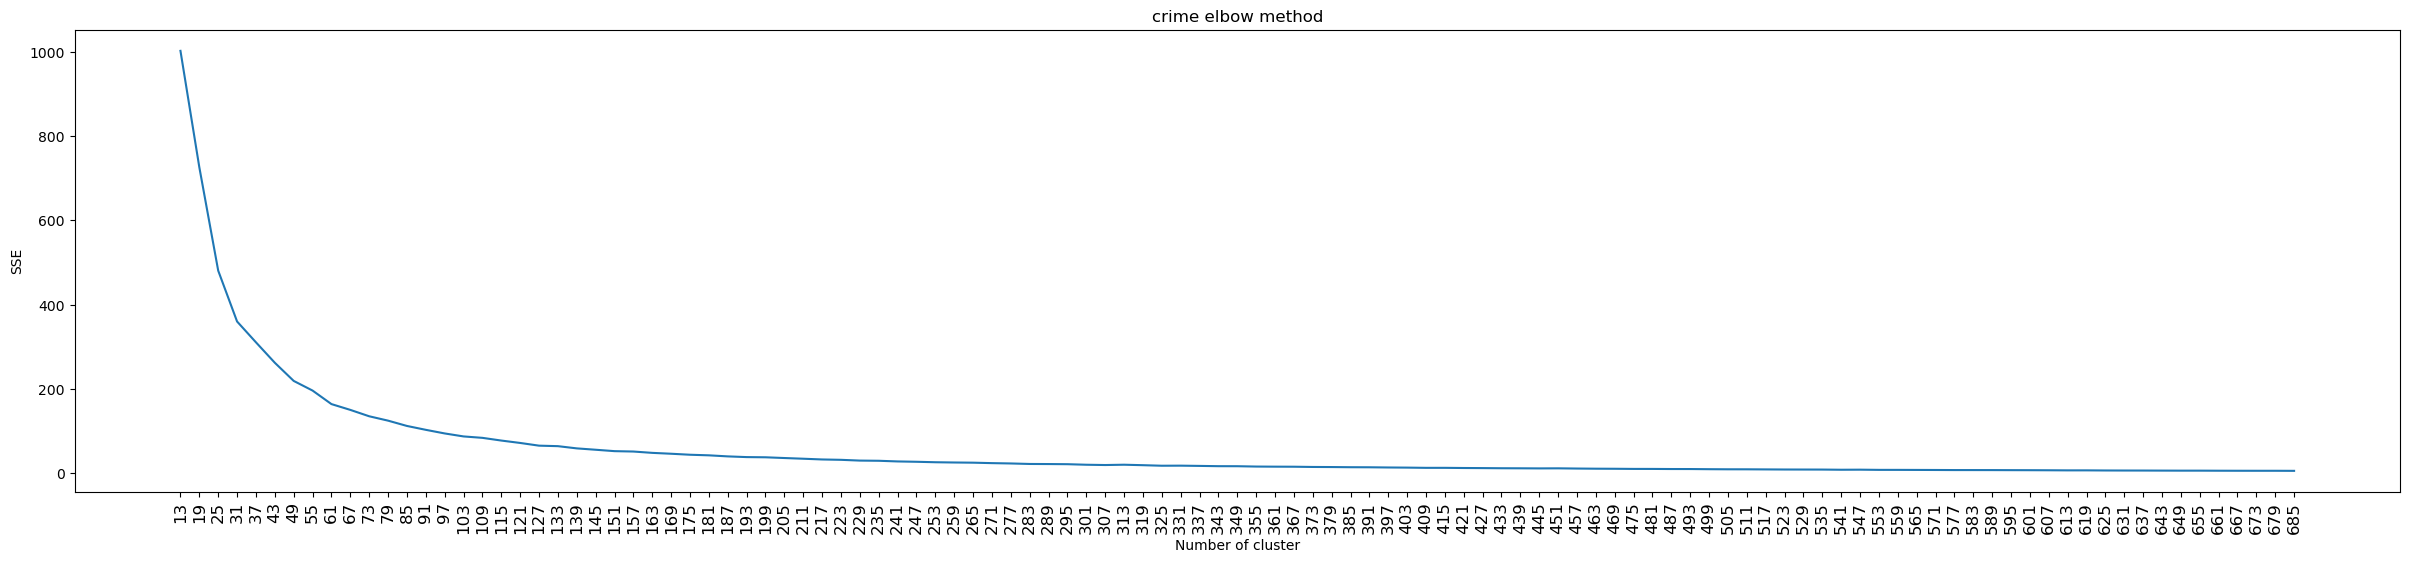

{11: 167.14606902403784, 16: 110.72789773491273, 21: 79.09985548389999, 26: 66.73329375325025, 31: 53.60977185916715, 36: 46.76740403443556, 41: 40.31411621441142, 46: 34.683415245894246, 51: 31.07333114369537, 56: 27.539744235089124, 61: 24.630665218530545, 66: 22.62082174814892, 71: 20.331884277306898, 76: 18.592105865422116, 81: 16.88428129962476, 86: 16.0474226911025, 91: 15.079477998756317, 96: 14.395022543102035, 101: 13.178547900097842, 106: 12.539613242967913, 111: 11.49266029221945, 116: 10.850176711223963, 121: 10.495859875544717, 126: 9.743509475700511, 131: 9.503363311490208, 136: 8.971382542942901, 141: 8.790579823170019, 146: 8.378586992232107, 151: 8.07445089656948, 156: 7.705732836737581, 161: 7.434408315215359, 166: 6.972297777232983, 171: 6.839669996354289, 176: 6.58245489109214, 181: 6.322611557527012, 186: 6.109025452858765, 191: 5.8750515177089495, 196: 5.62139485629105, 201: 5.529232539416458, 206: 5.443581424081883, 211: 5.0938821543390596, 216: 5.154610949434138

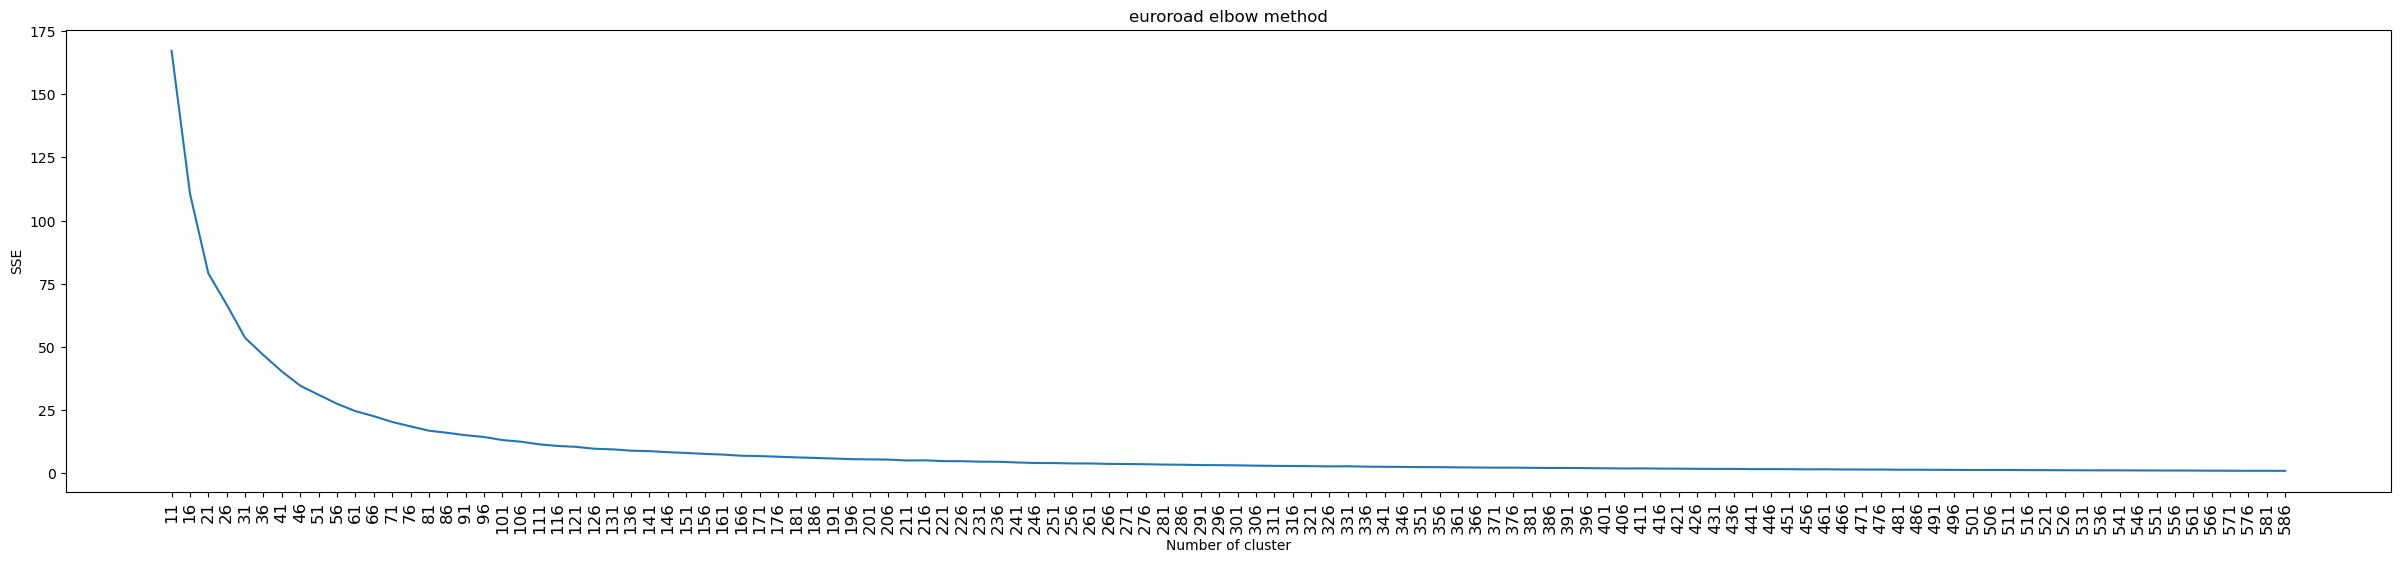

{15: 599211.3058486322, 22: 386818.76064789476, 29: 294466.14935849165, 36: 240073.13460261954, 43: 199571.61834216045, 50: 168444.47995850595, 57: 141252.89457600508, 64: 128048.49792892198, 71: 112840.5106496166, 78: 102276.73785923046, 85: 91021.5640241909, 92: 82980.34163674772, 99: 76875.8726240854, 106: 70024.65014832938, 113: 64545.79598951803, 120: 59897.11686074406, 127: 56382.69240782781, 134: 51785.28923533396, 141: 48914.52385011363, 148: 46204.11502220691, 155: 43303.60848590431, 162: 40362.314284267944, 169: 38385.78547232275, 176: 36158.09005910933, 183: 33848.64916153214, 190: 31913.022419874735, 197: 30522.58041750815, 204: 29559.89086891753, 211: 27412.414317861025, 218: 25975.906110590164, 225: 25045.778463543968, 232: 23891.803101821322, 239: 23187.466432211968, 246: 21304.165890828866, 253: 19535.87035189108, 260: 19174.53976282573, 267: 18881.371351095593, 274: 17938.531736460678, 281: 17436.05195376251, 288: 16330.684649491126, 295: 15835.908542576777, 302: 14872

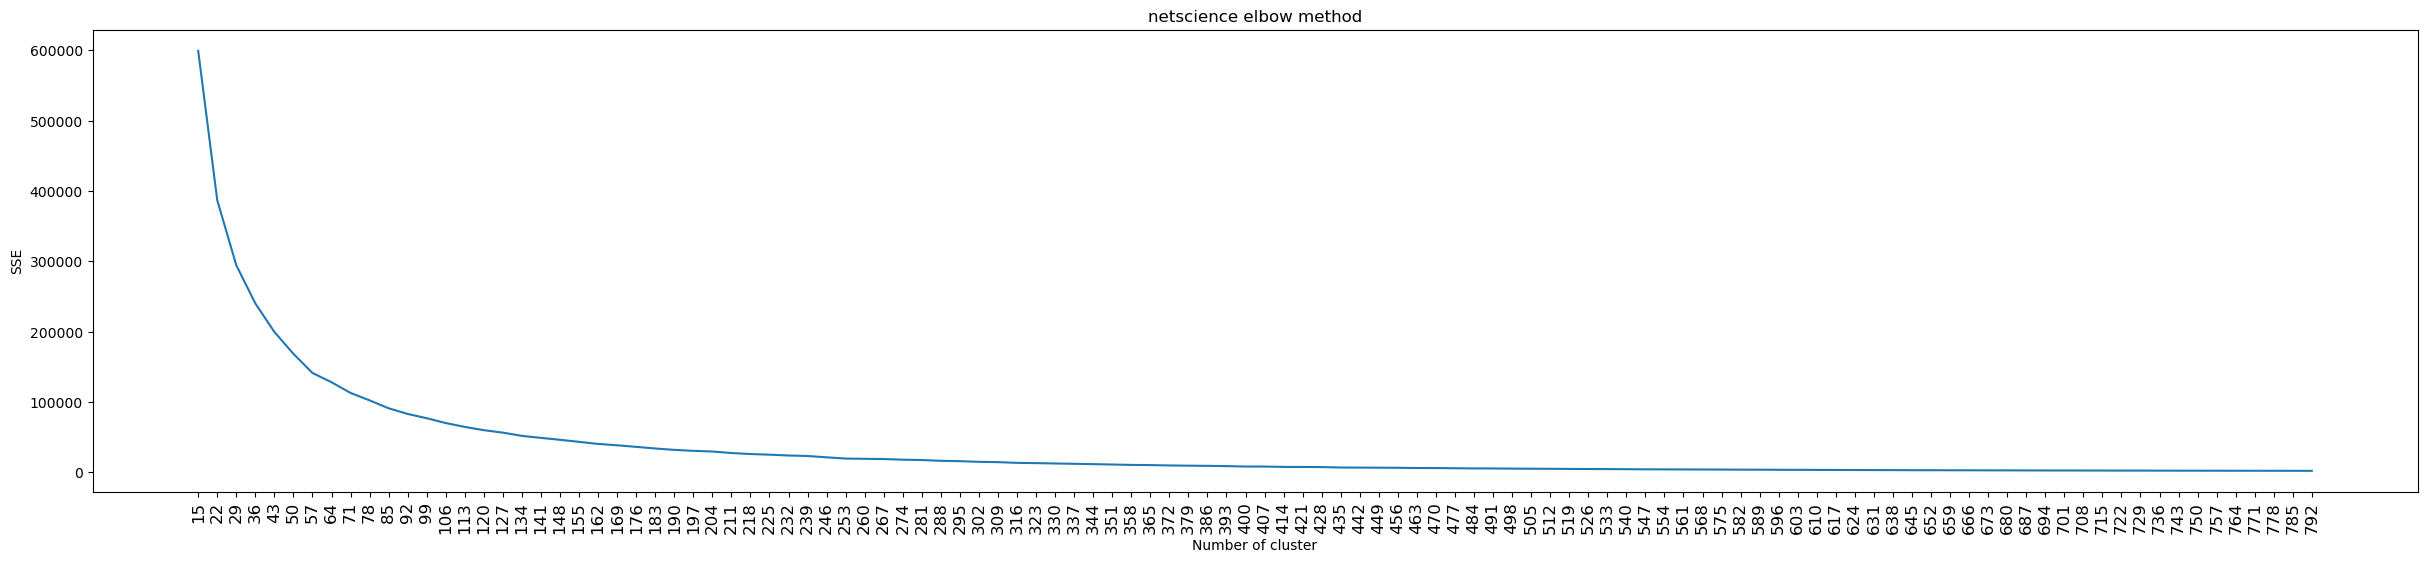

{49: 124.86167259625066, 73: 79.71622766609246, 97: 58.04285555932012, 121: 46.683351315879804, 145: 37.53315193011153, 169: 31.13368972216325, 193: 26.693095856060303, 217: 23.674571147646436, 241: 21.192001850810932, 265: 19.037149783232064, 289: 17.13681021387065, 313: 15.522821689673709, 337: 14.292281819870642, 361: 13.235127714448916, 385: 12.394142233892788, 409: 11.403786889425668, 433: 10.736941155079762, 457: 10.047785210516125, 481: 9.41109932487769, 505: 8.73008271296035, 529: 8.385761974916848, 553: 7.9644258722902155, 577: 7.514754611612705, 601: 7.184260195772837, 625: 6.8609593867778464, 649: 6.601848333295336, 673: 6.219857709458549, 697: 5.9674246393419486, 721: 5.800747050913088, 745: 5.484823621892099, 769: 5.232954805319636, 793: 5.082930824068291, 817: 4.902537318660476, 841: 4.755939357382731, 865: 4.562614784767649, 889: 4.400639020608066, 913: 4.277145017921772, 937: 4.152998842367076, 961: 3.9870793058987446, 985: 3.880339884083042, 1009: 3.7233816474333987, 1

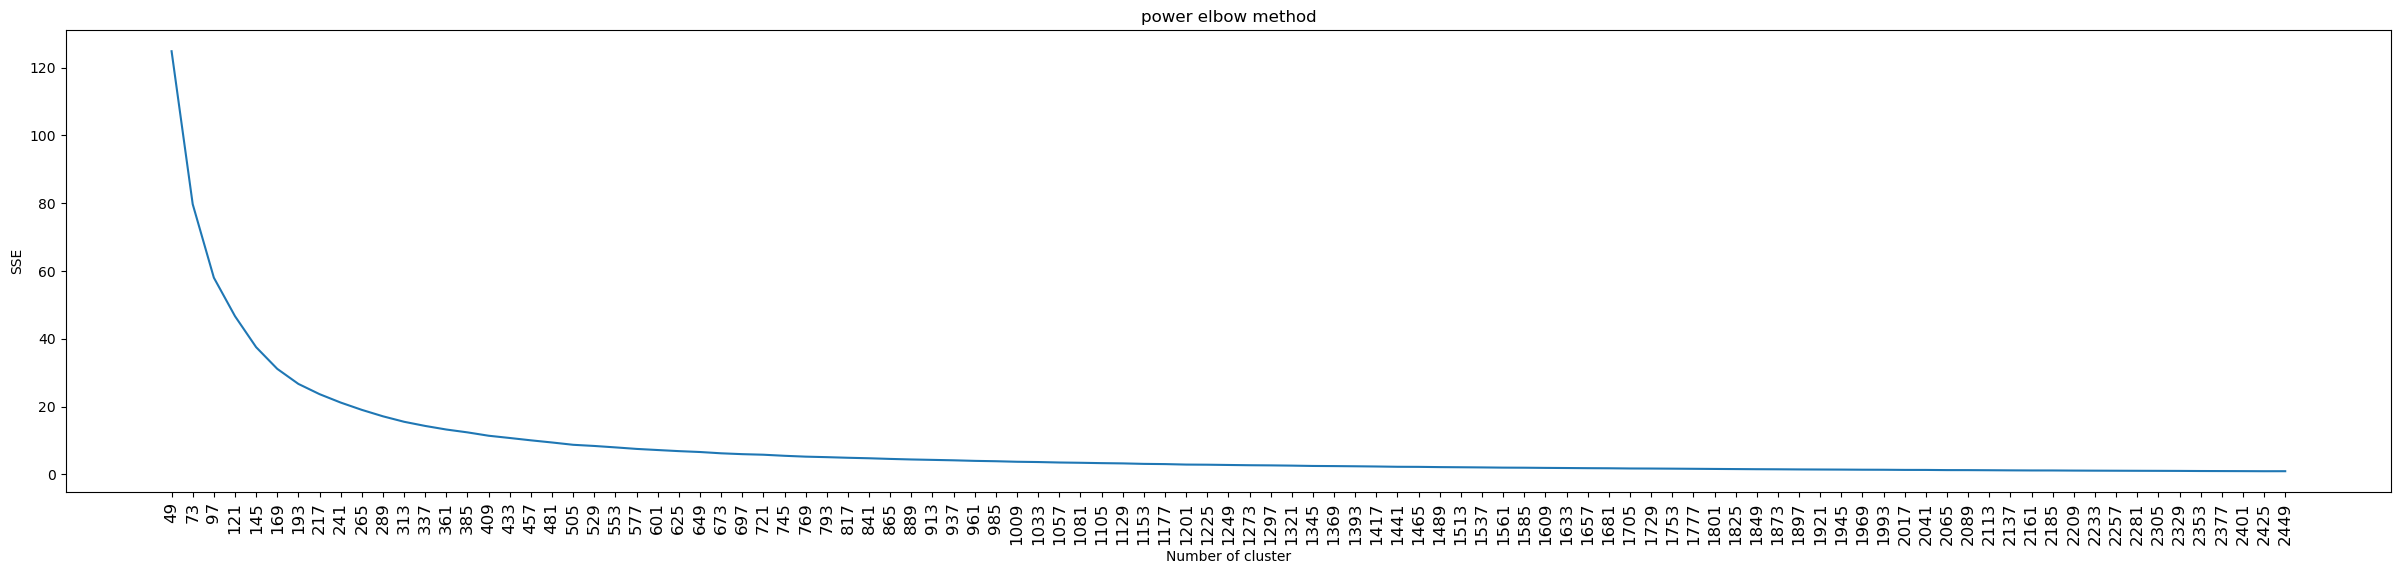

{6: 6.559318575484515, 9: 4.153039351921277, 12: 2.8185264862532837, 15: 1.984253492122018, 18: 1.6915180569765136, 21: 1.3518675162992282, 24: 1.159954300388173, 27: 1.009808179591938, 30: 0.9234967319651896, 33: 0.8225931468538319, 36: 0.7228352437688215, 39: 0.6782414582229412, 42: 0.6208703959963743, 45: 0.5967751553735356, 48: 0.5228152532943761, 51: 0.49516452000767897, 54: 0.4682511325463547, 57: 0.43518145476934145, 60: 0.4023238017021284, 63: 0.37769401481199605, 66: 0.3692429007730659, 69: 0.33845589373985147, 72: 0.3205729415236501, 75: 0.3143539721768272, 78: 0.3023712450324002, 81: 0.28250602282351744, 84: 0.26850343864960147, 87: 0.25749655421127343, 90: 0.24894998491088383, 93: 0.24237480183448243, 96: 0.23286002134232536, 99: 0.22954679817075835, 102: 0.2106420949548955, 105: 0.20408529099556028, 108: 0.2017669671310093, 111: 0.1903176975012219, 114: 0.18518992224872324, 117: 0.1799705470973501, 120: 0.17761600952027704, 123: 0.16807563149888016, 126: 0.1638802383074291

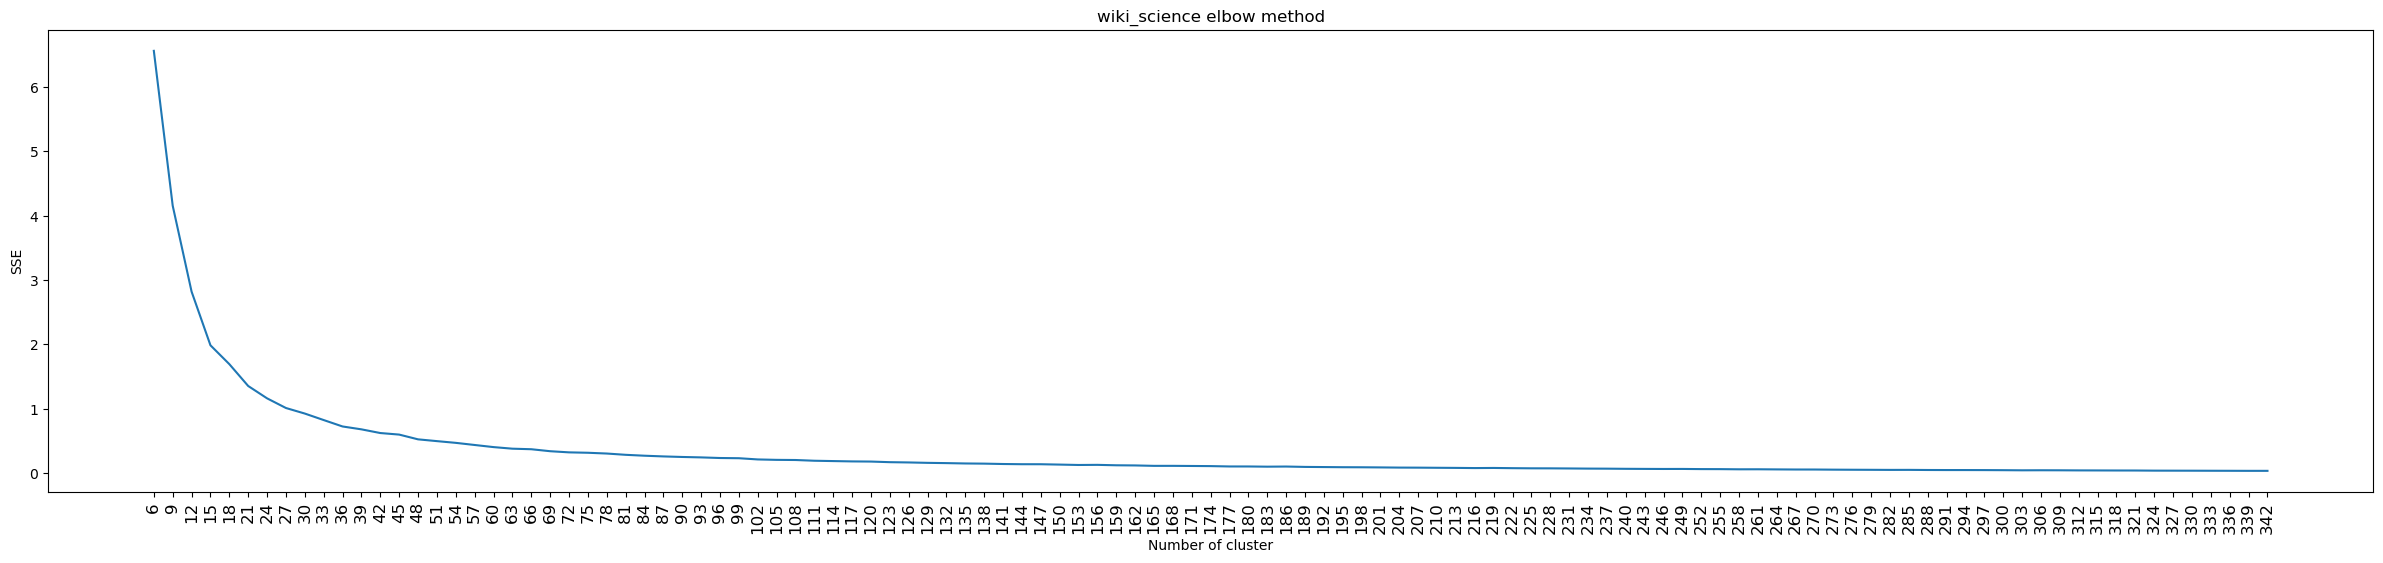

{16: 65108.13282820035, 24: 40871.662106689975, 32: 29855.15588865348, 40: 22576.59346067938, 48: 18786.678352855793, 56: 15722.936414401132, 64: 13473.355413276626, 72: 11759.357278188541, 80: 10082.409908450982, 88: 8971.363853647967, 96: 8307.04657144634, 104: 7345.535431655355, 112: 6429.052365790243, 120: 6040.699293948509, 128: 5541.366370412236, 136: 5036.87176521718, 144: 4767.542403245861, 152: 4219.656320509923, 160: 3896.5248320345495, 168: 3709.960780903125, 176: 3420.753308177376, 184: 3331.970148040759, 192: 3005.481337025482, 200: 2827.831518958202, 208: 2576.192276966679, 216: 2416.8943185817366, 224: 2294.5821110793268, 232: 2166.9003425315054, 240: 2075.8751303560866, 248: 1912.0940545933777, 256: 1813.6930961400103, 264: 1711.8253311654425, 272: 1580.8124141781136, 280: 1500.9804232687916, 288: 1419.5438102476653, 296: 1347.2334464168769, 304: 1275.0656019947087, 312: 1217.7959221895949, 320: 1149.2524439622289, 328: 1088.1244437756354, 336: 1016.5795232014983, 344: 

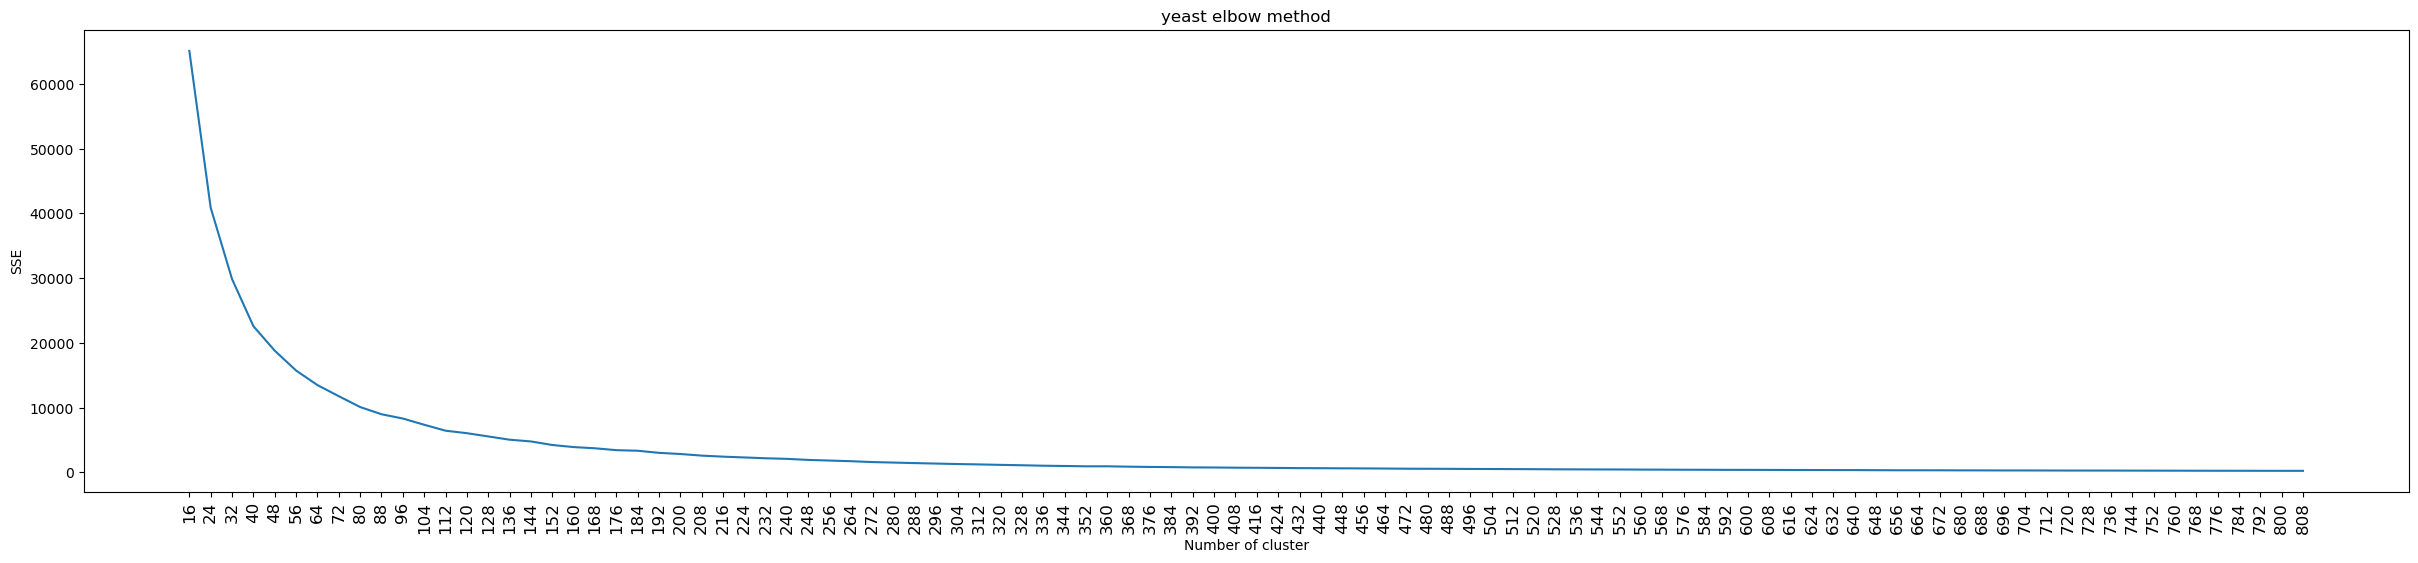

In [7]:
for data in ['crime', 'euroroad', 'netscience', 'power', 'wiki_science', 'yeast']:
    elbow_plot(data)